In [5]:
with open("subgenres.txt", "r", encoding="utf-8") as file:
    interests = file.read().strip().split(" | ")

interests

['Action',
 'Action Epic',
 'Adult Animation',
 'Adventure',
 'Adventure Epic',
 'Alien Invasion',
 'Animal Adventure',
 'Animation',
 'Anime',
 'Artificial Intelligence',
 'B-Action',
 'Baseball',
 'Basketball',
 'Beauty Competition',
 'Beauty Makeover',
 'B-Horror',
 'Biography',
 'Body Horror',
 'Body Swap Comedy',
 'Boxing',
 'Buddy Comedy',
 'Buddy Cop',
 'Bumbling Detective',
 'Business Reality TV',
 'Caper',
 'Car Action',
 'Classical Musical',
 'Classical Western',
 'Comedy',
 'Coming-of-Age',
 'Computer Animation',
 'Concert',
 'Conspiracy Thriller',
 'Contemporary Western',
 'Cooking & Food',
 'Cooking Competition',
 'Cop Drama',
 'Costume Drama',
 'Cozy Mystery',
 'Crime',
 'Crime Documentary',
 'Crime Reality TV',
 'Cyber Thriller',
 'Cyberpunk',
 'Dark Comedy',
 'Dark Fantasy',
 'Dark Romance',
 'Dating Reality TV',
 'Desert Adventure',
 'Dinosaur Adventure',
 'Disaster',
 'Docudrama',
 'Documentary',
 'Docuseries',
 'Docusoap Reality TV',
 'Drama',
 'Drug Crime',
 'Dystop

In [18]:
import re
import json

# Read the file
with open("subgenres info.txt", "r", encoding="utf-8") as file:
    lines = file.read().split("\n")

genre_list = []
first = True

for line_ind in range(len(lines)):
    line = lines[line_ind].strip()  # Strip whitespace
    
    if first:
        if line == "":
            first = False  # Next line will contain metadata
            continue  # Skip empty lines

        parts = line.split("\t", 1)  # Split title and description
        if len(parts) < 2:
            continue  # Skip malformed lines

        name, description = parts
        

    else:
        if line == "":
            first = True  # Reset for next entry
            continue

        # Extract metadata fields
        metadata = {}
        for item in line.split(" | "):
            key_value = item.split(": ")
            if len(key_value) == 2:
                key, value = key_value
                metadata[key.lower().replace(" ", "_")] = value  # Standardize keys

        # Store in list as a dictionary
        genre_list.append({
            "title": name,
            "description": description,
            **metadata  # Merge metadata fields into the dictionary
        })

# Save to JSON (Optional)
with open("parsed_subgenres.json", "w", encoding="utf-8") as json_file:
    json.dump(genre_list, json_file, indent=4, ensure_ascii=False)

# Print a sample entry
print(json.dumps(genre_list[:3], indent=4, ensure_ascii=False))  # Show first 3 entries


[
    {
        "title": "Action",
        "description": "The action genre features fast-paced, thrilling, and intense sequences of physical feats, combat, and excitement. The characters of these stories are involved in daring and often dangerous situations, requiring them to rely on their physical prowess, skills, and quick thinking to overcome challenges and adversaries.",
        "type": "Genre",
        "category": "Action",
        "required_genre": "Action",
        "required_keyword": "None"
    },
    {
        "title": "Action Epic",
        "description": "The action epic subgenre features fast-paced action with a grand and sweeping narrative scope, often spanning across vast landscapes, historical eras, and larger-than-life characters and conflicts. Classically, an epic tells the heroic journey and deeds of a single person, or group of persons, upon which the fate of many people depends.",
        "type": "Subgenre",
        "category": "Action",
        "required_genre": "

In [13]:
lines

['Action\tThe action genre features fast-paced, thrilling, and intense sequences of physical feats, combat, and excitement. The characters of these stories are involved in daring and often dangerous situations, requiring them to rely on their physical prowess, skills, and quick thinking to overcome challenges and adversaries.',
 '',
 'Type: Genre | Category: Action | Required Genre: Action | Required Keyword: None',
 '',
 'Action Epic\tThe action epic subgenre features fast-paced action with a grand and sweeping narrative scope, often spanning across vast landscapes, historical eras, and larger-than-life characters and conflicts. Classically, an epic tells the heroic journey and deeds of a single person, or group of persons, upon which the fate of many people depends.',
 '',
 'Type: Subgenre | Category: Action | Required Genre: None | Required Keyword: epic-action',
 '',
 "Adult Animation\tThe adult animation subgenre is aimed at mature audiences, typically consisting of content that e

### SUB-GENRES

In [38]:
import re
import os

def get_subgenre(sub_genre = "artificial-intelligence-sci-fi"):

    with open(f"subgenre-films/{sub_genre}.txt", 'r', encoding='utf-8') as file:
            lines = file.readlines()

    lines = [line.strip() for line in lines]

    pattern = r'(\b\d{1,4})\. '

    titles = []
    
    for line in lines:
        title = re.split(pattern, line)
        if len(title) > 1:
            titles.append(title[2])

    return titles

subgenres_dict = {}
subgenres = [f.replace(".txt", "") for f in os.listdir("subgenre-films/") if f.endswith(".txt")]

for sg in subgenres:
    titles = get_subgenre(sub_genre = sg)
    subgenres_dict[sg] = titles

print(len(subgenres_dict["artificial-intelligence-sci-fi"]))

196


In [39]:
counts = [len(subgenres_dict[sg]) for sg in subgenres]
min(counts)

39

In [46]:
with open("subgenres_movies.json", 'w', encoding='utf-8') as f:
        json.dump(subgenres_dict, f, ensure_ascii=False, indent=4)

print("Data saved to json file")

Data saved to json file


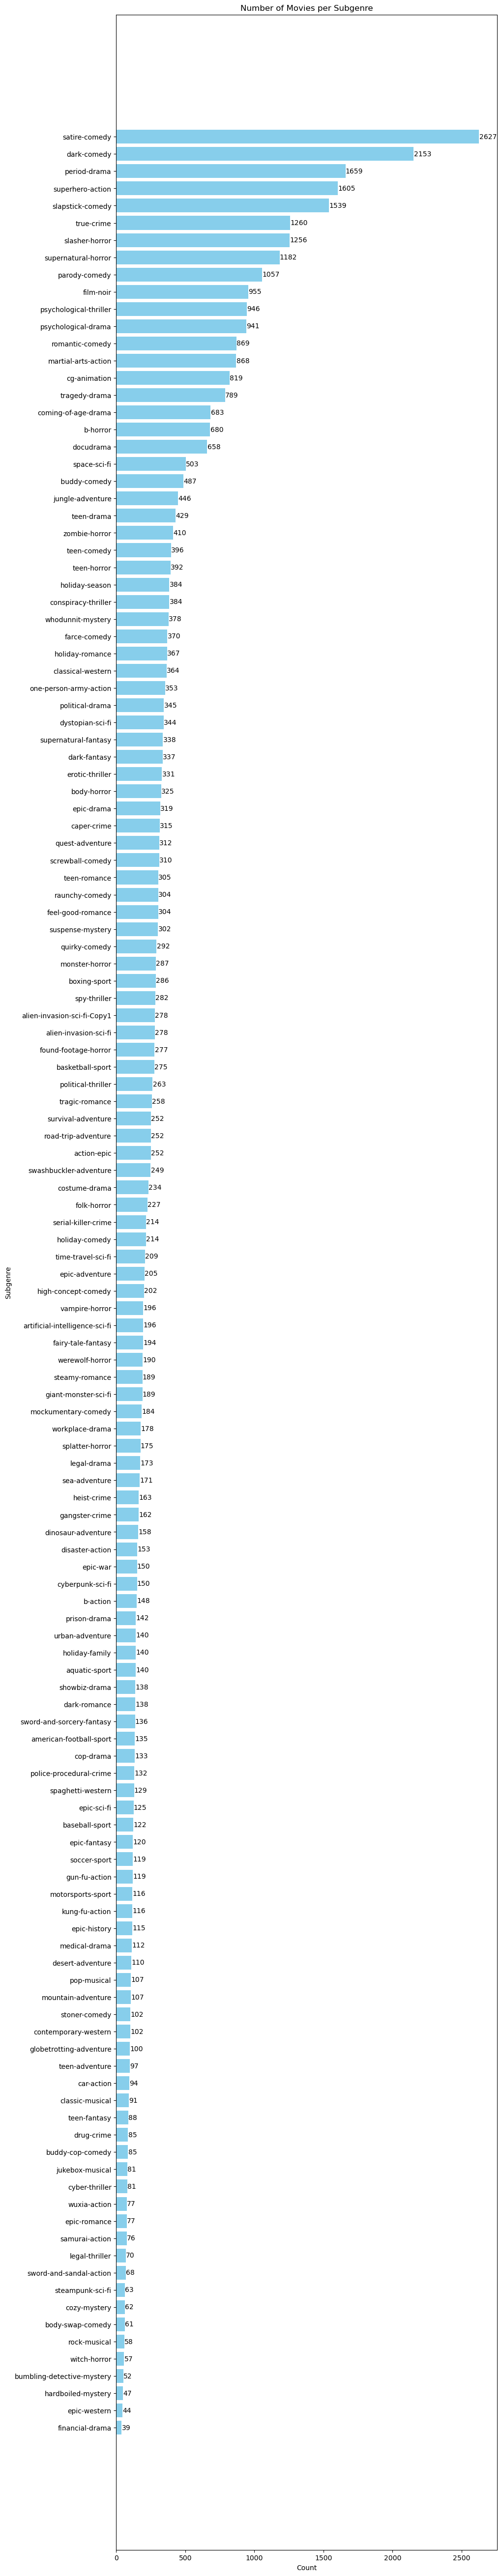

In [45]:
import matplotlib.pyplot as plt

def plot_horizontal_barplot(subgenres, counts):
    # Sort subgenres and counts in descending order
    sorted_pairs = sorted(zip(counts, subgenres), reverse=False)
    counts_sorted, subgenres_sorted = zip(*sorted_pairs)
    
    fig, ax = plt.subplots(figsize=(10, len(subgenres) * 0.5))  # Adjust height dynamically

    bars = ax.barh(subgenres_sorted, counts_sorted, color='skyblue')

    # Annotate each bar with its count value
    for bar, count in zip(bars, counts_sorted):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,  # Position to the right
                str(count), ha='left', va='center', color='black', fontsize=10)

    ax.set_xlabel("Count")
    ax.set_ylabel("Subgenre")
    ax.set_title("Number of Movies per Subgenre")
    plt.savefig("subgenre_counts.pdf")

    plt.show()

plot_horizontal_barplot(subgenres, counts)
